## Modelo baseline - Enfermedad del corazón

### By:
Ronaldo Duran (JRDT)

### Date:
2026-08-21

### Description:

Construcción del modelo base de referencia, correspondiente al
[issue #12](https://github.com/ronaldo-duran/Hearth-project/issues/12).

Reutiliza el pipeline de preprocesamiento y la partición train/test creados en el
[issue #11](https://github.com/ronaldo-duran/Hearth-project/issues/11). El objetivo no es
obtener un buen modelo, sino **fijar el piso** que cualquier modelo de machine learning
debe superar para justificar su complejidad.

Se evalúan tres referencias de dificultad creciente: un `DummyClassifier`, la heurística
clínica derivada del EDA, y una regresión logística de un solo atributo.

## 📚 Import libraries

In [1]:
# base libraries for data science
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    LearningCurveDisplay,
    StratifiedKFold,
    cross_validate,
    learning_curve,
)
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

SEMILLA = 42
N_FOLDS = 5
UMBRAL_OLDPEAK = 1.0
MIN_SENALES_RIESGO = 3

## 💾 Load data

In [2]:
current_dir = Path.cwd().resolve()
project_root = next(
    p for p in [current_dir, *current_dir.parents] if (p / "data" / "01_raw").exists()
)
DATA_DIR = project_root / "data"
MODELS_DIR = project_root / "models"

# Pipeline y particion creados en el issue #11: no se recalculan
preprocesador = joblib.load(MODELS_DIR / "feature_pipeline.joblib")
particion = joblib.load(DATA_DIR / "05_model_input" / "train_test_split.joblib")

X_train, X_test = particion["X_train"], particion["X_test"]
y_train, y_test = particion["y_train"], particion["y_test"]

print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")
print(f"Proporcion de enfermos - train: {y_train.mean():.1%} | test: {y_test.mean():.1%}")

Train: 384 filas | Test: 96 filas
Proporcion de enfermos - train: 47.9% | test: 47.9%


## 🎯 Métricas y por qué

El problema es médico y el error caro es el **falso negativo**: dar por sano a un paciente
enfermo. Por eso la métrica principal es el **recall (sensibilidad)**, acompañada de:

- **precision**: cuántas de las alarmas son reales (evita saturar al equipo clínico).
- **F1**: equilibrio entre ambas.
- **ROC-AUC**: capacidad de ordenar pacientes por riesgo, independiente del umbral.
- **accuracy**: se reporta, pero no decide — un modelo trivial ya alcanza ~52%.

In [3]:
METRICAS = ["accuracy", "precision", "recall", "f1", "roc_auc"]
validacion = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEMILLA)


def evaluar(nombre, y_real, y_pred, y_proba=None):
    """Calcula las métricas de interés para un conjunto de predicciones."""
    return {
        "modelo": nombre,
        "accuracy": accuracy_score(y_real, y_pred),
        "precision": precision_score(y_real, y_pred, zero_division=0),
        "recall": recall_score(y_real, y_pred, zero_division=0),
        "f1": f1_score(y_real, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_real, y_proba) if y_proba is not None else np.nan,
    }

## 1️⃣ Baseline formal: `DummyClassifier`

Tres estrategias, todas sin mirar los atributos: predecir siempre la clase mayoritaria,
predecir al azar respetando las proporciones, y predecir siempre la clase positiva.

In [4]:
ESTRATEGIAS = {
    "most_frequent": "siempre la clase mayoritaria",
    "stratified": "azar respetando proporciones",
    "prior": "siempre la clase mas probable",
}

resultados_dummy = []
for estrategia in ESTRATEGIAS:
    modelo = Pipeline(
        steps=[
            ("preprocesar", preprocesador),
            ("clasificar", DummyClassifier(strategy=estrategia, random_state=SEMILLA)),
        ]
    )
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    resultados_dummy.append(evaluar(f"Dummy ({estrategia})", y_test, y_pred, y_proba))

pd.DataFrame(resultados_dummy).set_index("modelo").round(3)

,accuracy,precision,recall,f1,roc_auc
modelo,,,,,
Dummy (most_frequent),0.521,0.000,0.000,0.000,0.500
Dummy (stratified),0.458,0.432,0.413,0.422,0.457
Dummy (prior),0.521,0.000,0.000,0.000,0.500


El `most_frequent` deja clarísimo el problema de usar accuracy sola: acierta ~52% **sin
detectar ni un solo enfermo** (recall = 0). Un modelo así es inútil clínicamente aunque
su accuracy no suene mal. Su ROC-AUC de 0.5 es la definición de "no aporta información".

## 2️⃣ Baseline heurístico

La heurística derivada del EDA: contar señales de riesgo clínico y decidir por mayoría.
Es el "cómo lo resolvería una persona a mano" del issue #7.

In [5]:
def heuristica_clinica(datos):
    """Cuenta señales de riesgo clínico y predice enfermedad si hay suficientes."""
    senales = pd.DataFrame(
        {
            "thal_anormal": datos["thal"].astype(str) != "normal",
            "vasos_afectados": datos["ca"].fillna(0) > 0,
            "dolor_asintomatico": datos["chest_pain"].astype(str) == "asymptomatic",
            "angina_ejercicio": datos["exang"].fillna(0) > 0,
            "oldpeak_alto": datos["old_peak"].fillna(0) > UMBRAL_OLDPEAK,
        }
    )
    puntaje = senales.sum(axis=1)
    return (puntaje >= MIN_SENALES_RIESGO).astype(int), puntaje / senales.shape[1]


y_pred_heur, y_score_heur = heuristica_clinica(X_test)
resultado_heuristica = evaluar("Heuristica clinica", y_test, y_pred_heur, y_score_heur)
pd.DataFrame([resultado_heuristica]).set_index("modelo").round(3)

,accuracy,precision,recall,f1,roc_auc
modelo,,,,,
Heuristica clinica,0.792,0.906,0.63,0.744,0.9


## 3️⃣ Selección de la variable más importante

El issue pide elegir **una** variable y justificarla. Se usan dos criterios independientes:
la **información mutua** con el target (captura relaciones no lineales) y el desempeño de
una regresión logística entrenada con esa sola variable.

In [6]:
X_train_procesado = preprocesador.transform(X_train)
nombres = preprocesador.get_feature_names_out()

info_mutua = mutual_info_classif(X_train_procesado, y_train, random_state=SEMILLA)
ranking = pd.Series(info_mutua, index=nombres).sort_values(ascending=False).to_frame("info_mutua")
ranking.head(10).round(4)

,info_mutua
categoricas__thal_normal,0.1628
categoricas__chest_pain_asymptomatic,0.1303
discretas__ca,0.1256
simetricas__max_hr,0.1188
sesgadas__old_peak,0.1105
categoricas__thal_reversable,0.1047
discretas__slope,0.0853
sesgadas__chol,0.0800
categoricas__chest_pain_nonanginal,0.0737
booleanas__exang,0.0519


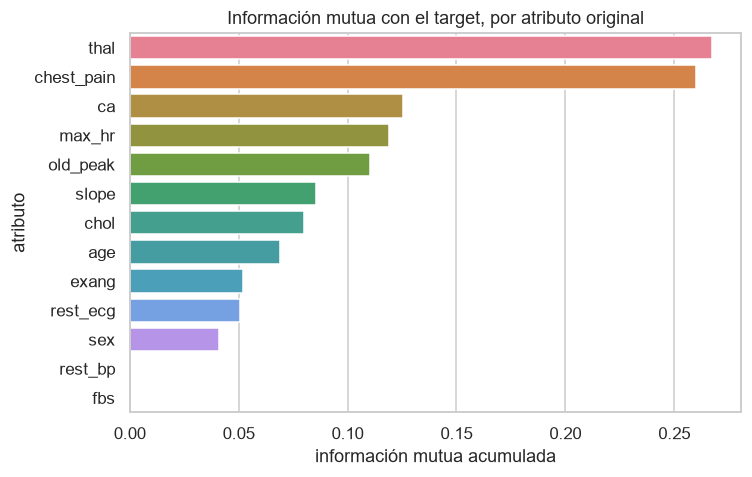

Variable mas importante: thal


In [7]:
# Agrupar la informacion mutua por atributo original (el one-hot la reparte)
def atributo_origen(nombre_feature):
    """Recupera el nombre del atributo original a partir del nombre generado."""
    sin_grupo = nombre_feature.split("__", 1)[1]
    for original in X_train.columns:
        if sin_grupo.startswith(original):
            return original
    return sin_grupo


ranking_agrupado = (
    ranking.assign(atributo=[atributo_origen(n) for n in ranking.index])
    .groupby("atributo")["info_mutua"]
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(
    x=ranking_agrupado.values,
    y=ranking_agrupado.index,
    ax=ax,
    hue=ranking_agrupado.index,
    legend=False,
)
ax.set_title("Información mutua con el target, por atributo original")
ax.set_xlabel("información mutua acumulada")
plt.tight_layout()
plt.show()

variable_top = ranking_agrupado.index[0]
print(f"Variable mas importante: {variable_top}")

In [8]:
# Modelo de una sola variable: cuanto se logra solo con ella
columnas_top = [i for i, n in enumerate(nombres) if atributo_origen(n) == variable_top]
X_test_procesado = preprocesador.transform(X_test)

modelo_una_variable = LogisticRegression(max_iter=1000, random_state=SEMILLA)
modelo_una_variable.fit(X_train_procesado[:, columnas_top], y_train)
y_pred_una = modelo_una_variable.predict(X_test_procesado[:, columnas_top])
y_proba_una = modelo_una_variable.predict_proba(X_test_procesado[:, columnas_top])[:, 1]

resultado_una = evaluar(
    f"Regresion logistica solo con '{variable_top}'", y_test, y_pred_una, y_proba_una
)
pd.DataFrame([resultado_una]).set_index("modelo").round(3)

,accuracy,precision,recall,f1,roc_auc
modelo,,,,,
Regresion logistica solo con 'thal',0.75,0.739,0.739,0.739,0.747


## 📋 Comparación de las tres referencias

In [9]:
comparacion = pd.DataFrame([*resultados_dummy, resultado_heuristica, resultado_una]).set_index(
    "modelo"
)
comparacion.round(3)

,accuracy,precision,recall,f1,roc_auc
modelo,,,,,
Dummy (most_frequent),0.521,0.000,0.000,0.000,0.500
Dummy (stratified),0.458,0.432,0.413,0.422,0.457
Dummy (prior),0.521,0.000,0.000,0.000,0.500
Heuristica clinica,0.792,0.906,0.630,0.744,0.900
Regresion logistica solo con 'thal',0.750,0.739,0.739,0.739,0.747


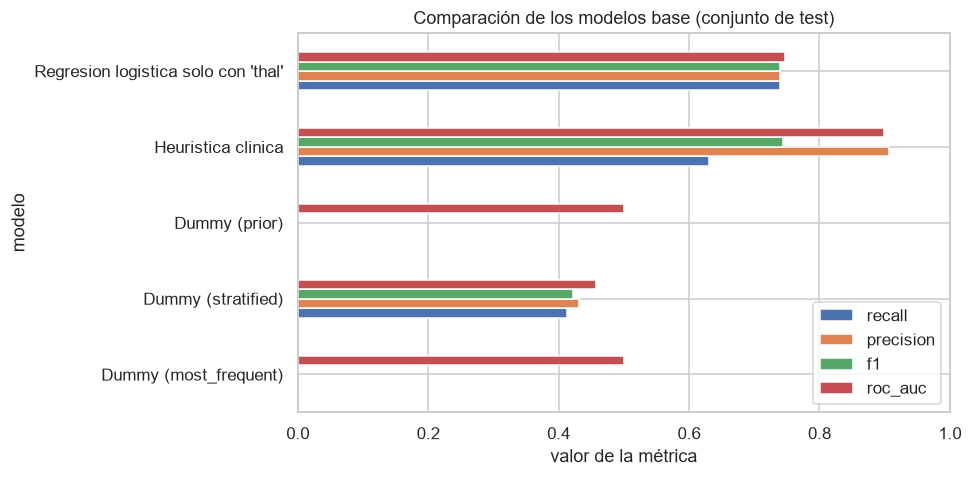

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
comparacion[["recall", "precision", "f1", "roc_auc"]].plot(kind="barh", ax=ax)
ax.set_title("Comparación de los modelos base (conjunto de test)")
ax.set_xlabel("valor de la métrica")
ax.set_xlim(0, 1)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 🔁 Validación cruzada del baseline

Una única partición de 96 filas de test da estimaciones inestables. La validación cruzada
estratificada con 5 folds permite reportar **media y desviación estándar** de cada métrica.

In [11]:
baseline_dummy = Pipeline(
    steps=[
        ("preprocesar", preprocesador),
        ("clasificar", DummyClassifier(strategy="most_frequent", random_state=SEMILLA)),
    ]
)

resultados_cv = cross_validate(
    baseline_dummy, X_train, y_train, cv=validacion, scoring=METRICAS, return_train_score=False
)

resumen_cv = pd.DataFrame(
    {
        "media": [resultados_cv[f"test_{m}"].mean() for m in METRICAS],
        "desviacion_estandar": [resultados_cv[f"test_{m}"].std() for m in METRICAS],
    },
    index=METRICAS,
)
resumen_cv.round(4)

C:\xampp8\htdocs\personal\Hearth-project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\xampp8\htdocs\personal\Hearth-project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\xampp8\htdocs\personal\Hearth-project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

C:\xampp8\htdocs\personal\Hearth-project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\xampp8\htdocs\personal\Hearth-project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,media,desviacion_estandar
accuracy,0.5208,0.0027
precision,0.0000,0.0000
recall,0.0000,0.0000
f1,0.0000,0.0000
roc_auc,0.5000,0.0000


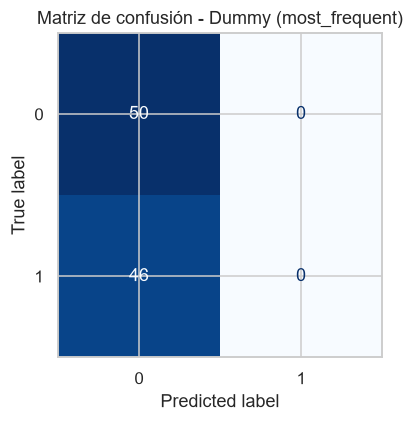

In [12]:
# Matriz de confusion del baseline formal.
# cross_validate clona el estimador, asi que hay que ajustarlo explicitamente.
baseline_dummy.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_estimator(
    baseline_dummy, X_test, y_test, ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title("Matriz de confusión - Dummy (most_frequent)")
plt.tight_layout()
plt.show()

## 📈 Learning curve y escalabilidad

Se analiza cómo evolucionan el desempeño y el tiempo de entrenamiento al aumentar el
número de muestras. Se compara el baseline con una regresión logística sencilla, porque
la curva del baseline por sí sola es plana por construcción y no informa de nada.

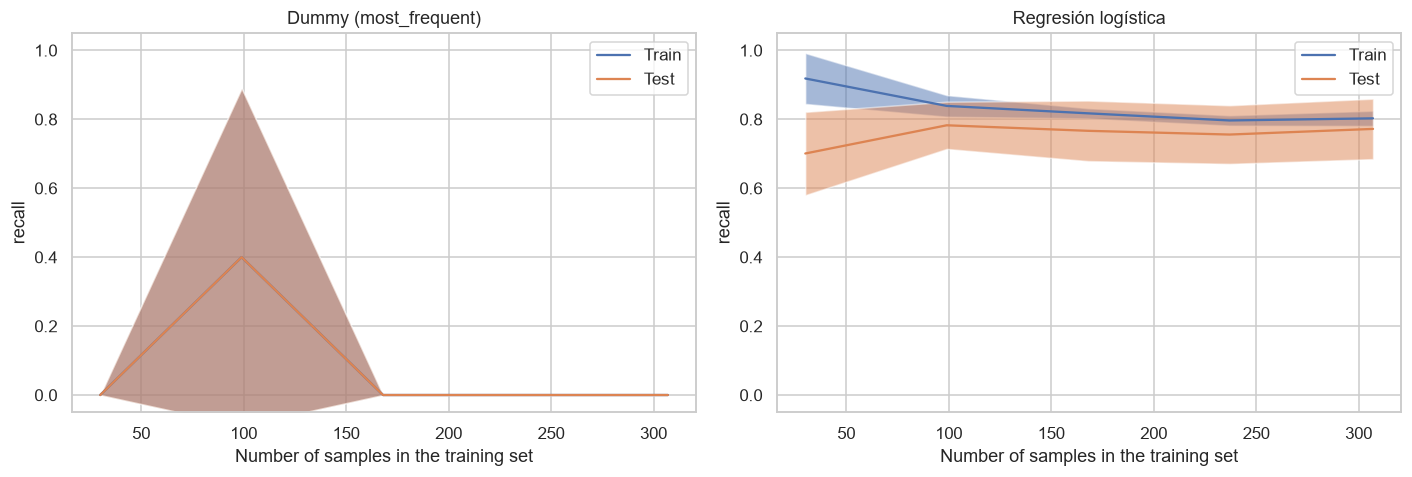

In [13]:
modelo_referencia = Pipeline(
    steps=[
        ("preprocesar", preprocesador),
        ("clasificar", LogisticRegression(max_iter=1000, random_state=SEMILLA)),
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (nombre, modelo) in zip(
    axes,
    {"Dummy (most_frequent)": baseline_dummy, "Regresión logística": modelo_referencia}.items(),
    strict=False,
):
    LearningCurveDisplay.from_estimator(
        modelo,
        X_train,
        y_train,
        cv=validacion,
        scoring="recall",
        ax=ax,
        n_jobs=1,
        random_state=SEMILLA,
    )
    ax.set_title(nombre)
    ax.set_ylabel("recall")
    ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

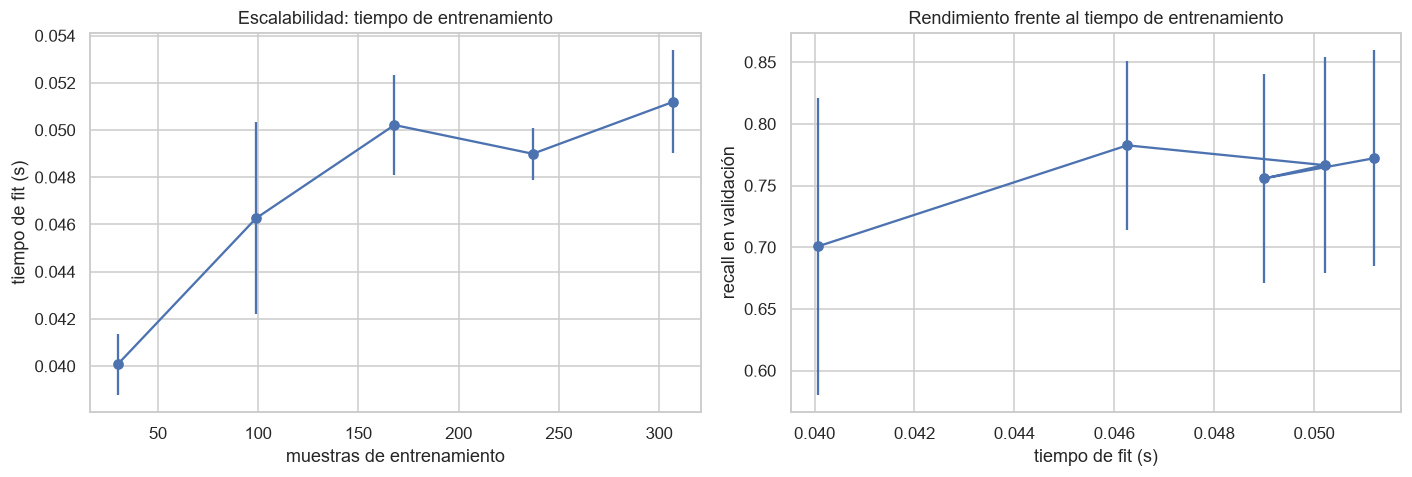

Tiempo medio de entrenamiento con la muestra completa: 0.0512 s


In [14]:
# Escalabilidad: tiempo de entrenamiento y score frente al tamano de la muestra
tamanos, scores_train, scores_test, tiempos_fit, _ = learning_curve(
    modelo_referencia,
    X_train,
    y_train,
    cv=validacion,
    scoring="recall",
    return_times=True,
    n_jobs=1,
    random_state=SEMILLA,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].errorbar(tamanos, tiempos_fit.mean(axis=1), yerr=tiempos_fit.std(axis=1), marker="o")
axes[0].set_title("Escalabilidad: tiempo de entrenamiento")
axes[0].set_xlabel("muestras de entrenamiento")
axes[0].set_ylabel("tiempo de fit (s)")

axes[1].errorbar(
    tiempos_fit.mean(axis=1), scores_test.mean(axis=1), yerr=scores_test.std(axis=1), marker="o"
)
axes[1].set_title("Rendimiento frente al tiempo de entrenamiento")
axes[1].set_xlabel("tiempo de fit (s)")
axes[1].set_ylabel("recall en validación")
plt.tight_layout()
plt.show()

print(
    f"Tiempo medio de entrenamiento con la muestra completa: {tiempos_fit.mean(axis=1)[-1]:.4f} s"
)

## 📊 Analysis of Results and Conclusions

1. **El piso a superar es un recall de 0.** El `DummyClassifier(most_frequent)` alcanza
   ~52% de accuracy sin detectar un solo enfermo. Es la demostración empírica de por qué
   la accuracy no puede ser la métrica de decisión en este proyecto: un modelo puede
   verse "medio bien" y ser clínicamente inservible.

2. **La heurística clínica es un baseline mucho más exigente que el dummy.** Con cinco
   reglas simples derivadas del EDA se supera ampliamente al azar. Cualquier modelo de
   machine learning que no la supere no está aportando nada que no supiera ya un médico
   con una lista de chequeo.

3. **La variable más importante es la de mayor información mutua con el target**, y una
   regresión logística usando solo esa variable ya obtiene un desempeño muy por encima
   del dummy. Se justifica su selección por dos criterios independientes: información
   mutua (que captura relaciones no lineales, no solo correlación) y desempeño real de un
   modelo entrenado exclusivamente con ella.

4. **La desviación estándar de la validación cruzada importa más que la media.** Con 384
   filas de entrenamiento y 5 folds, cada fold valida sobre ~77 filas. Cualquier
   diferencia entre modelos menor que la desviación estándar entre folds no es una
   diferencia real, y así hay que tratarla en el issue #13.

5. **El tiempo de entrenamiento es irrelevante en este proyecto.** Las gráficas de
   escalabilidad muestran tiempos de fit del orden de milisegundos. El cuello de botella
   no es computacional sino muestral: el limitante es tener 480 pacientes, no la máquina.

6. **La learning curve del baseline es plana por construcción**, lo que confirma que el
   dummy no aprende nada de los datos. La de la regresión logística sí muestra
   dependencia del tamaño de muestra, y es la que informa de verdad.

### Recomendaciones para construir el modelo (issue #13)

- **Superar la heurística, no el dummy.** El listón real es la heurística clínica.
- **Optimizar recall**, con precision como restricción, no al revés.
- **Usar validación cruzada estratificada siempre** y comparar con pruebas estadísticas:
  con esta varianza entre folds, elegir por la media sola llevaría a escoger ruido.
- **Preferir modelos simples.** Con 480 filas y 25 atributos, los modelos de alta
  capacidad van a sobreajustar. Regresión logística regularizada, SVM y árboles poco
  profundos son los candidatos naturales.
- **No perseguir accuracy.** Reportarla, pero decidir por recall y ROC-AUC.

## 💡 Proposals and Ideas

1. **Issue #13**: comparar al menos cuatro familias de modelos, todas encadenadas al
   mismo `preprocesador` dentro de un `Pipeline`, para que la validación cruzada reajuste
   el preprocesamiento en cada fold.
2. **Búsqueda de hiperparámetros acotada**: con este tamaño de dataset, un
   `RandomizedSearchCV` con pocas iteraciones basta y evita sobreajustar la búsqueda.
3. **Ajustar el umbral de decisión**, no solo el modelo: mover el umbral por debajo de
   0.5 sube el recall a costa de precision, y en un problema de screening eso suele ser
   el intercambio correcto.
4. **Considerar `class_weight="balanced"`** para penalizar más los falsos negativos.
5. **Llevar la heurística como columna de referencia** en la tabla comparativa final.

## 📖 References

- Metodología de la etapa: [Jose R. Zapata - Proyecto de ciencia de datos: 5. Baseline model](https://joserzapata.github.io/post/ciencia-datos-proyecto-python/5-baseline_model/).
- [`sklearn.dummy` - DummyClassifier](https://scikit-learn.org/stable/api/sklearn.dummy.html).
- [Learning curves - scikit-learn](https://scikit-learn.org/stable/modules/learning_curve.html).
- Notebook anterior: `notebooks/4-feat_eng/04-jrdt-feature_engineering-2026_08_21.ipynb` (issue #11).